## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [5]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

0

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [8]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [13]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [14]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.8 Adding columns for "Total Score" and "Average"

In [15]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [17]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )

#### 4.1 Overview of Categorical Columns Distribution

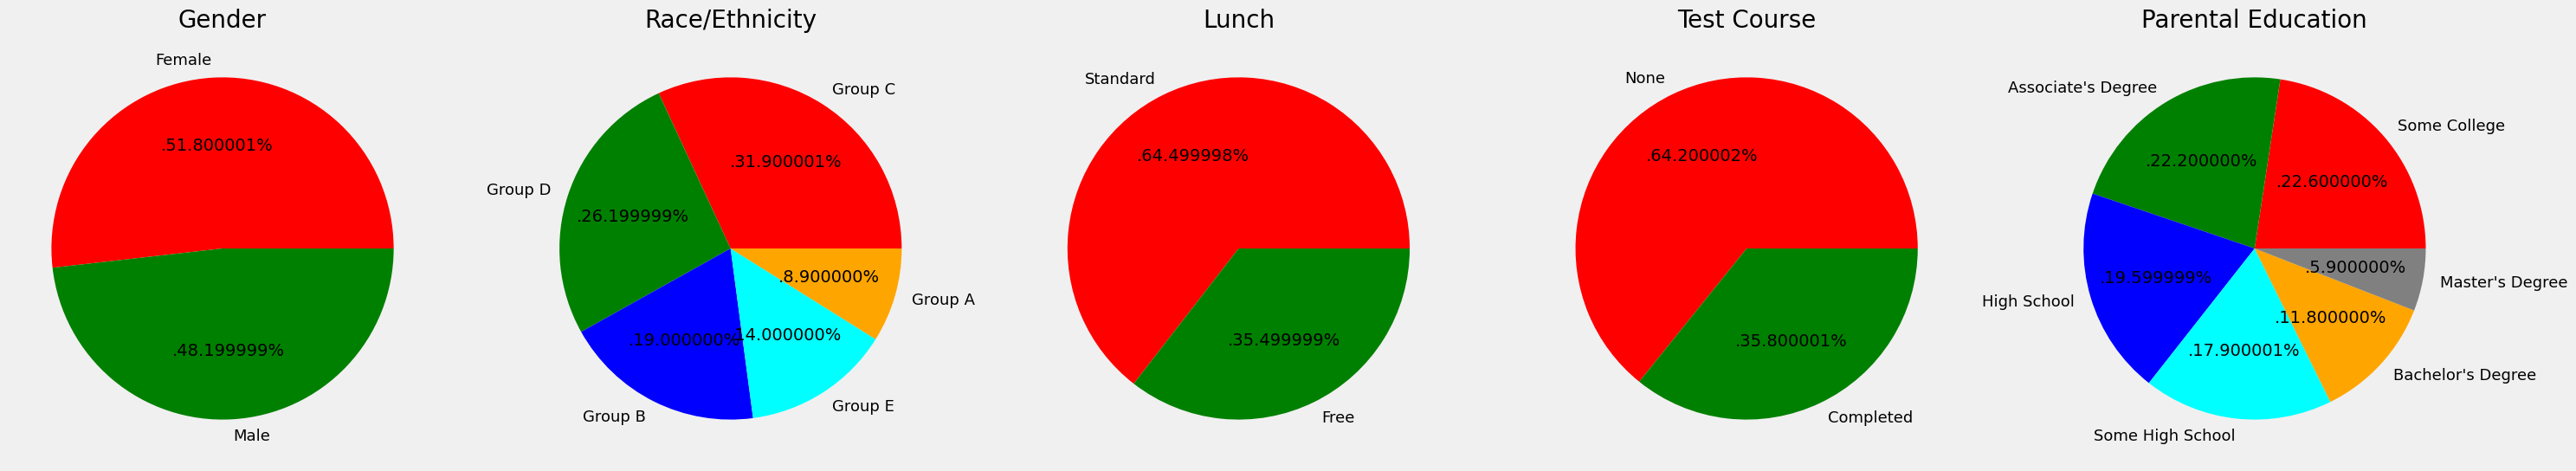

In [53]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

### 4.2 Overview of Numerical Columns Distribution

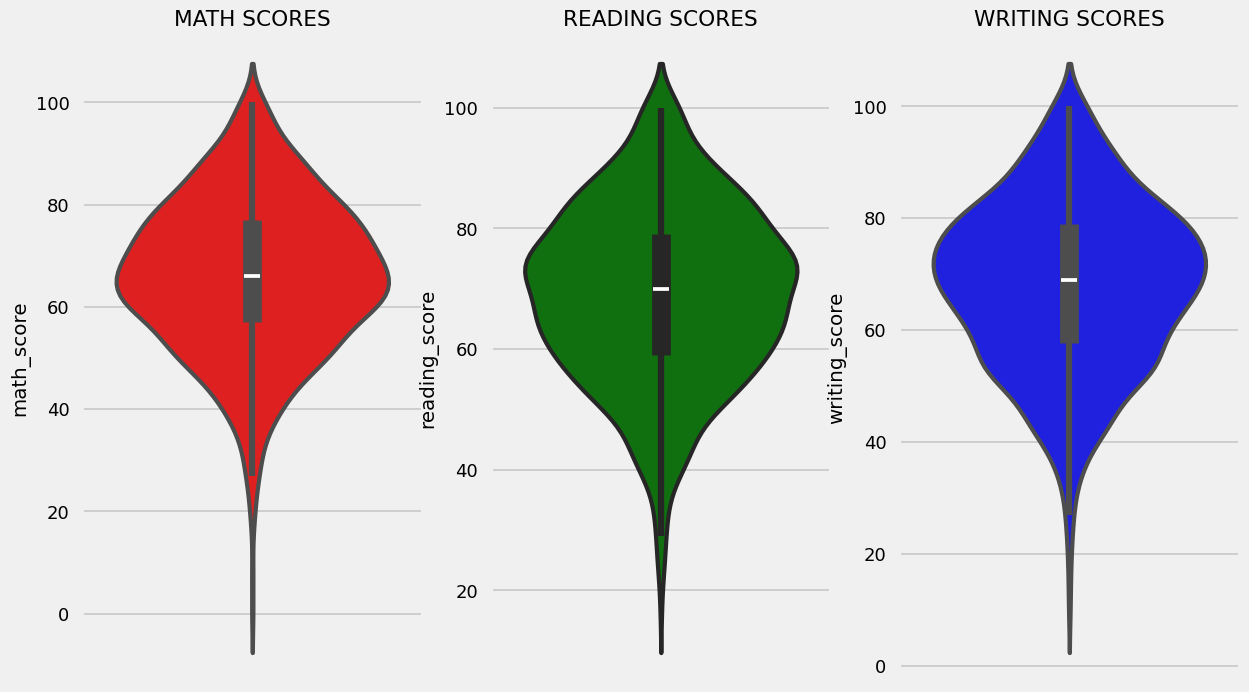

In [54]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score', data=df, color='red', linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)
plt.show()

##### Insights
- All 3 subjects show roughly normal distribution 
  (widest in the middle, narrow at extremes)

- Math scores have the widest spread — more variation 
  in student performance compared to reading and writing

- Reading and writing distributions are very similar 
  in shape, confirming their high correlation (0.95)

- Median math score (~66) is slightly lower than 
  reading (~68) and writing (~68)

- All 3 subjects have a thin tail reaching near 0 — 
  confirming the few very low scoring outliers found earlier

- Most students score between 55-80 across all subjects 
  (widest part of violin)

#### 4.3 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.3.1 Histogram & KDE For gender COlumn

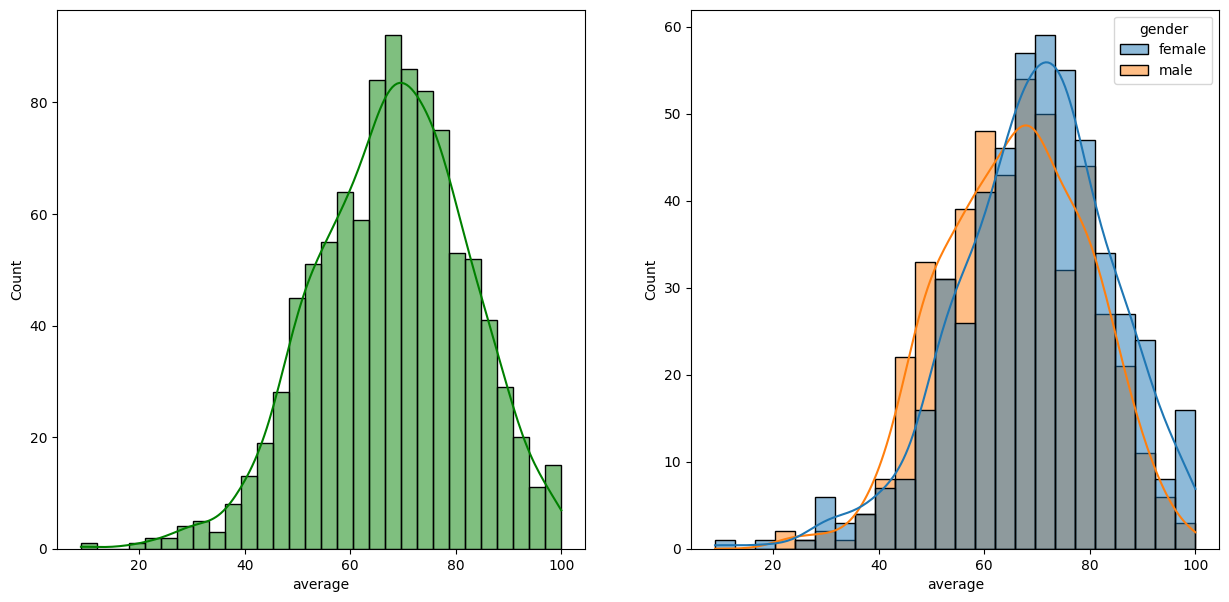

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

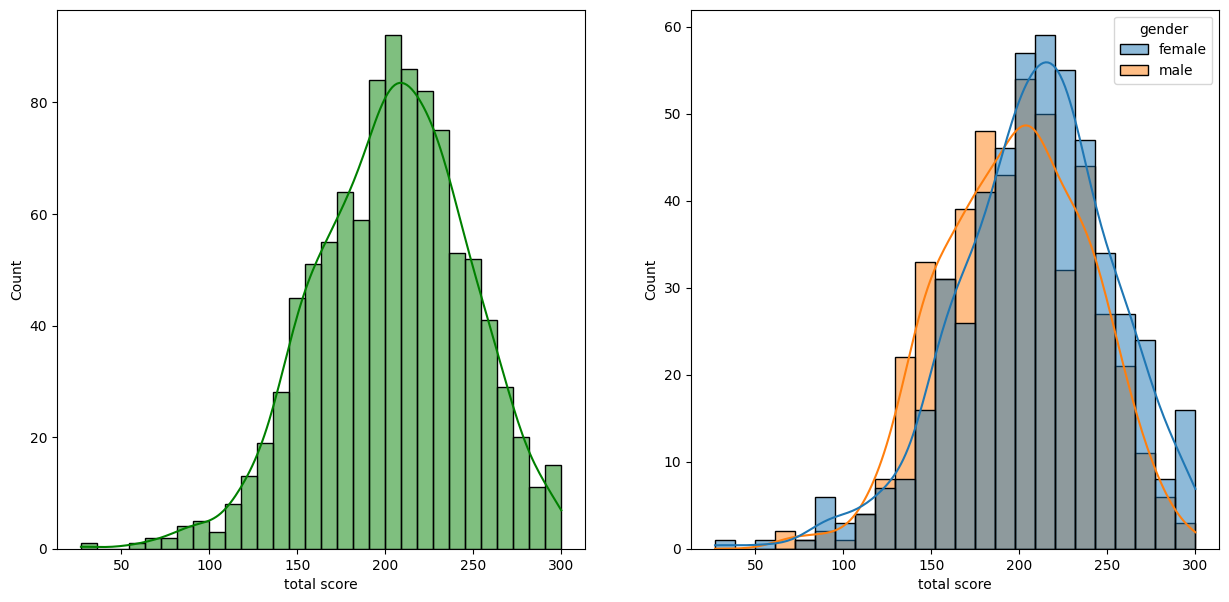

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

#####  Insights
- Female students tend to perform well then male students.

#### 4.3.2 Histogram & KDE For lunch Column

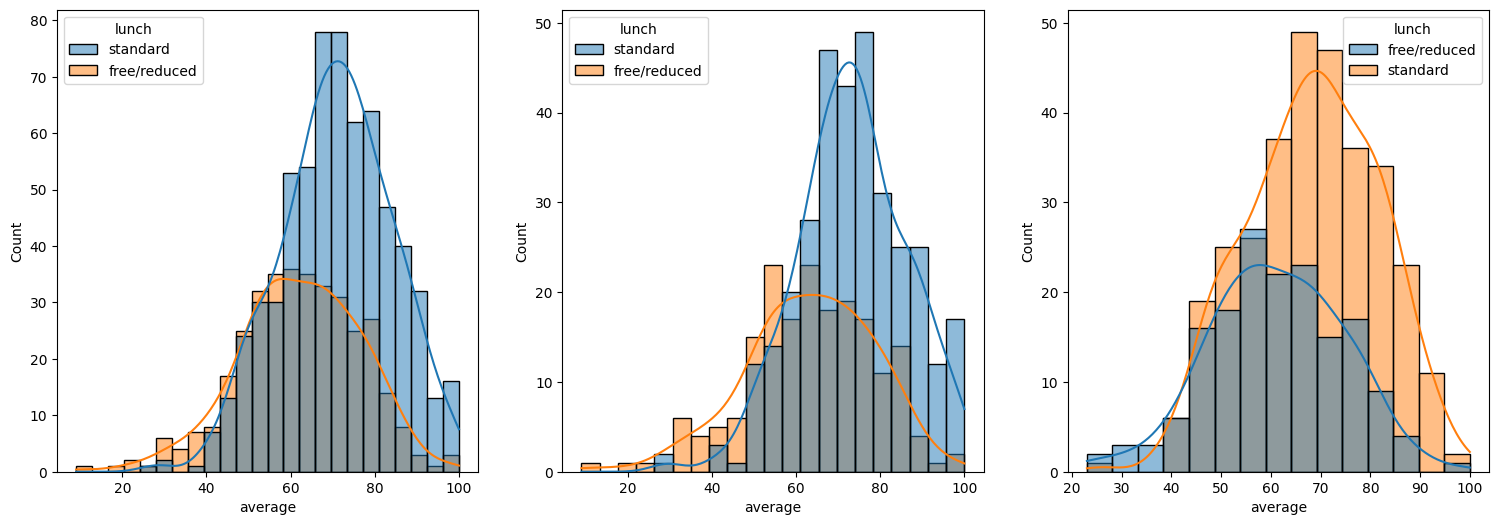

In [20]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

#### 4.3.3 Histogram & KDE For parental_level_of_education Column

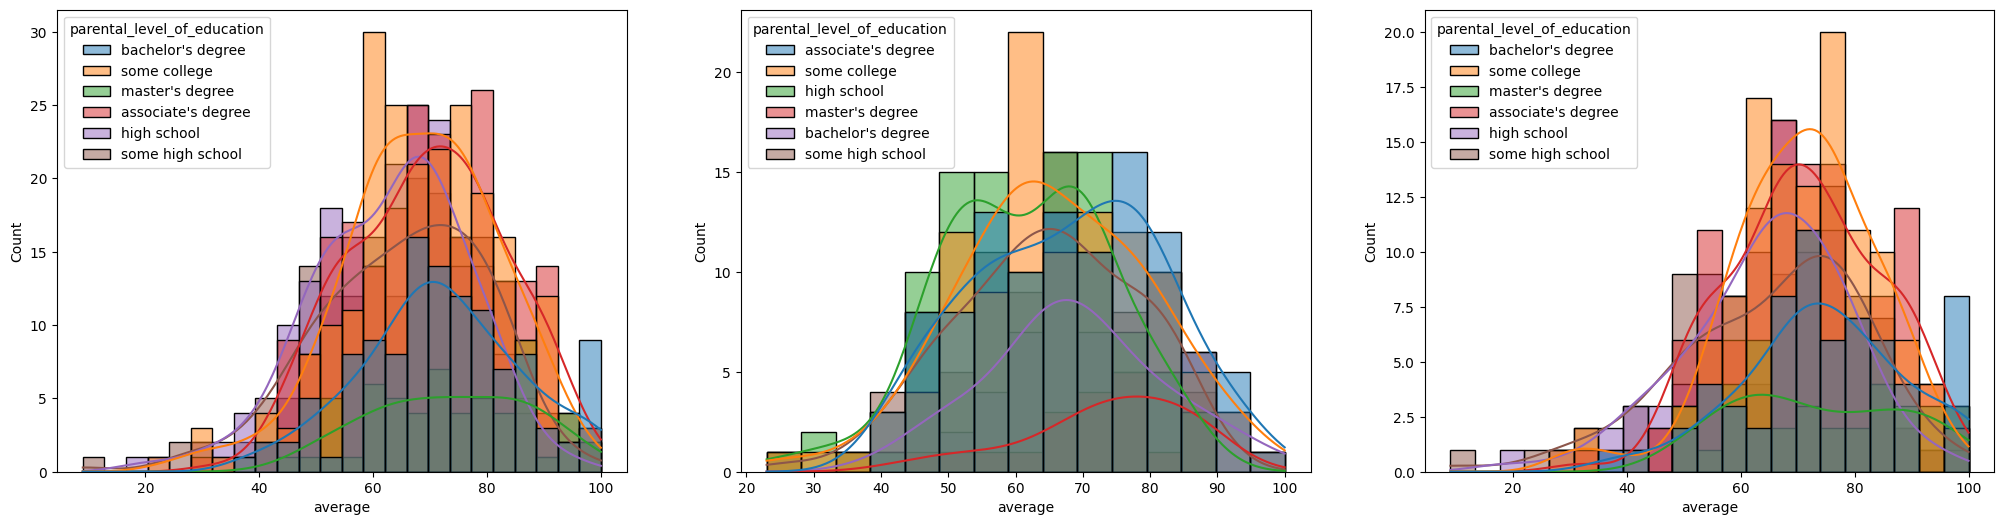

In [21]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax = sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education')
plt.subplot(132)
ax = sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='parental_level_of_education')
plt.subplot(133)
ax = sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental_level_of_education')
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

#### 4.3.4 Histogram & KDE For race_ethnicity Column

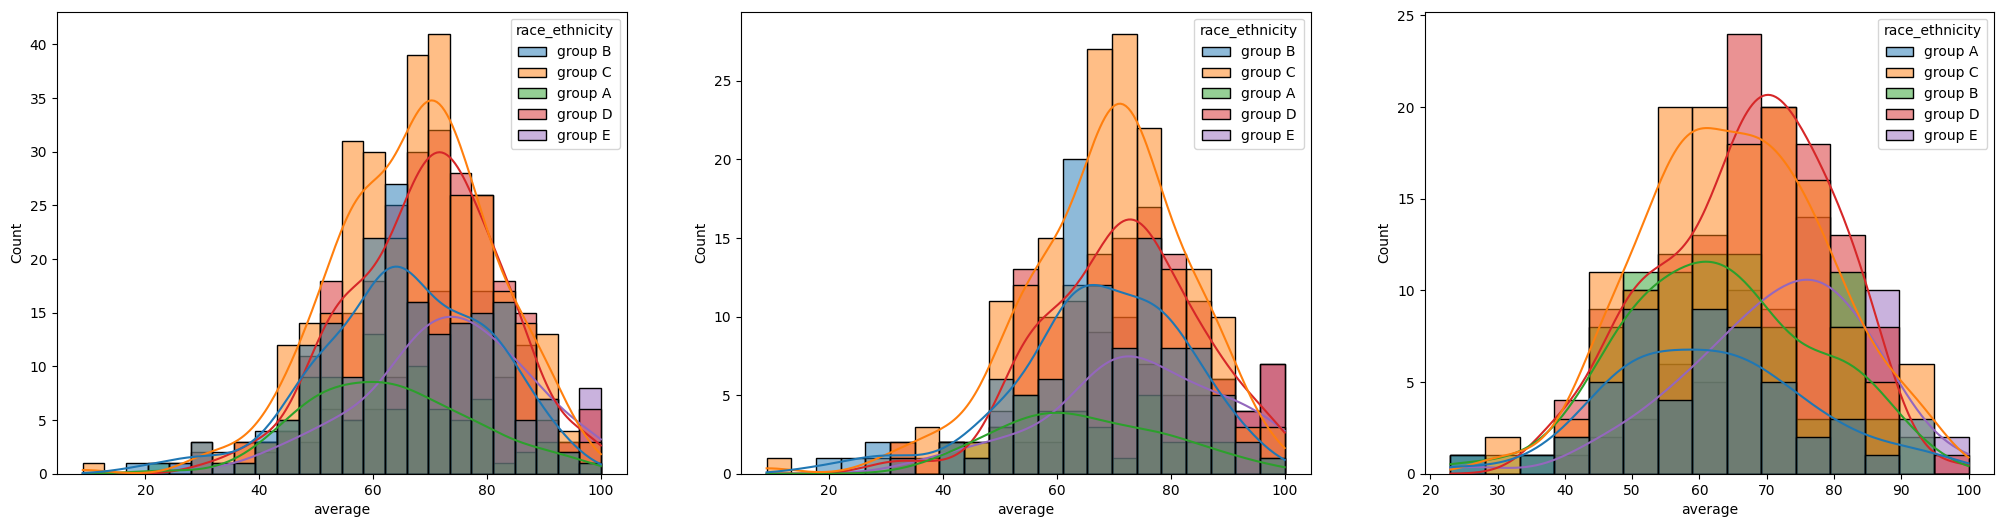

In [22]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax = sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity')
plt.subplot(132)
ax = sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='race_ethnicity')
plt.subplot(133)
ax = sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='race_ethnicity')
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.3.5 Histogram & KDE For test_preparation_course Column

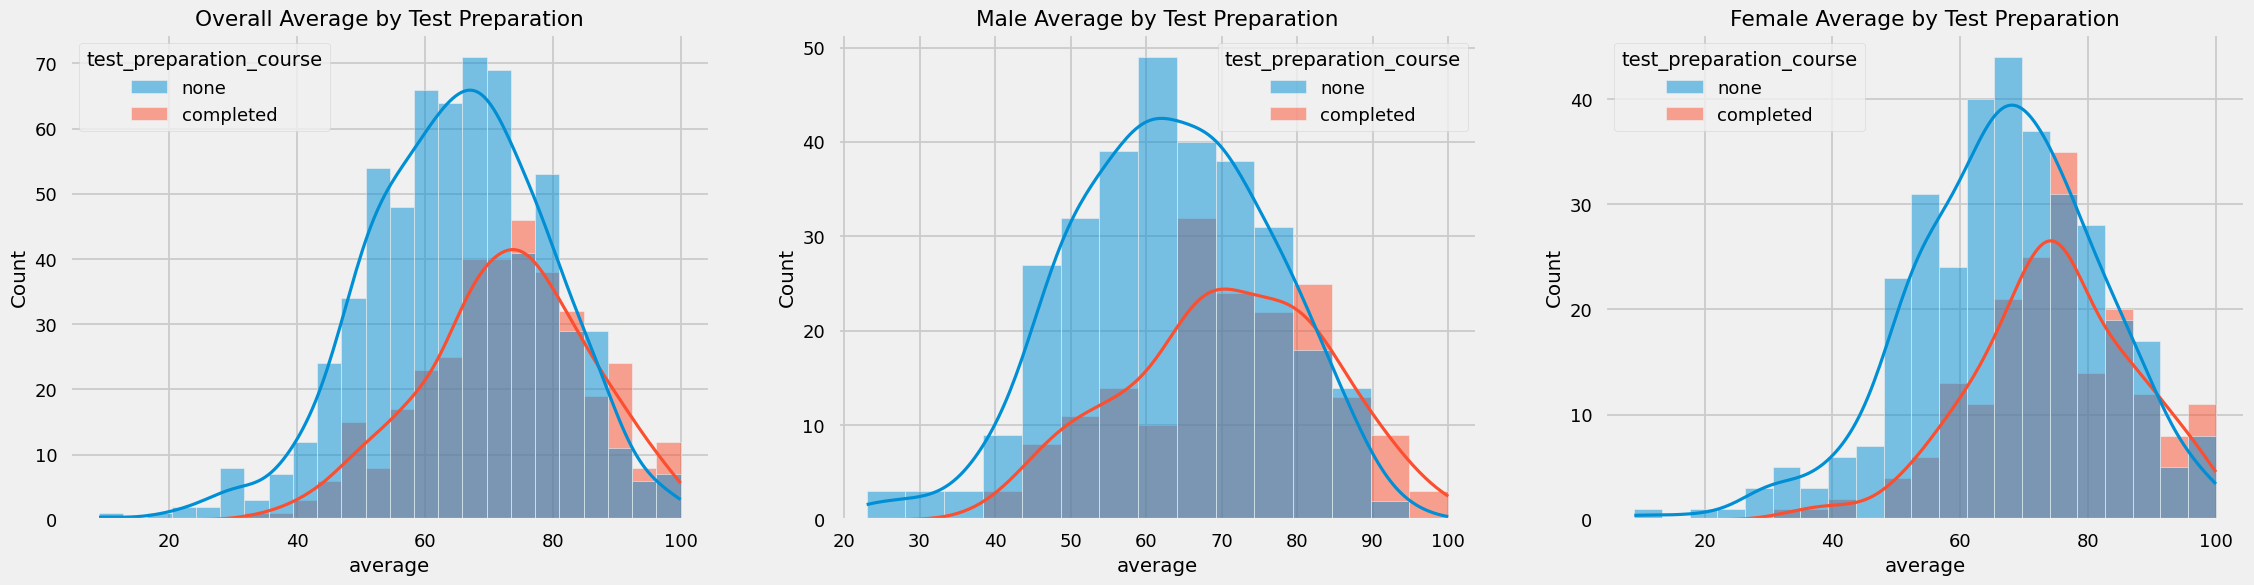

In [55]:
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(131)
ax = sns.histplot(data=df, x='average', kde=True, hue='test_preparation_course')
plt.title('Overall Average by Test Preparation')

plt.subplot(132)
ax = sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='test_preparation_course')
plt.title('Male Average by Test Preparation')

plt.subplot(133)
ax = sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='test_preparation_course')
plt.title('Female Average by Test Preparation')

plt.show()

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

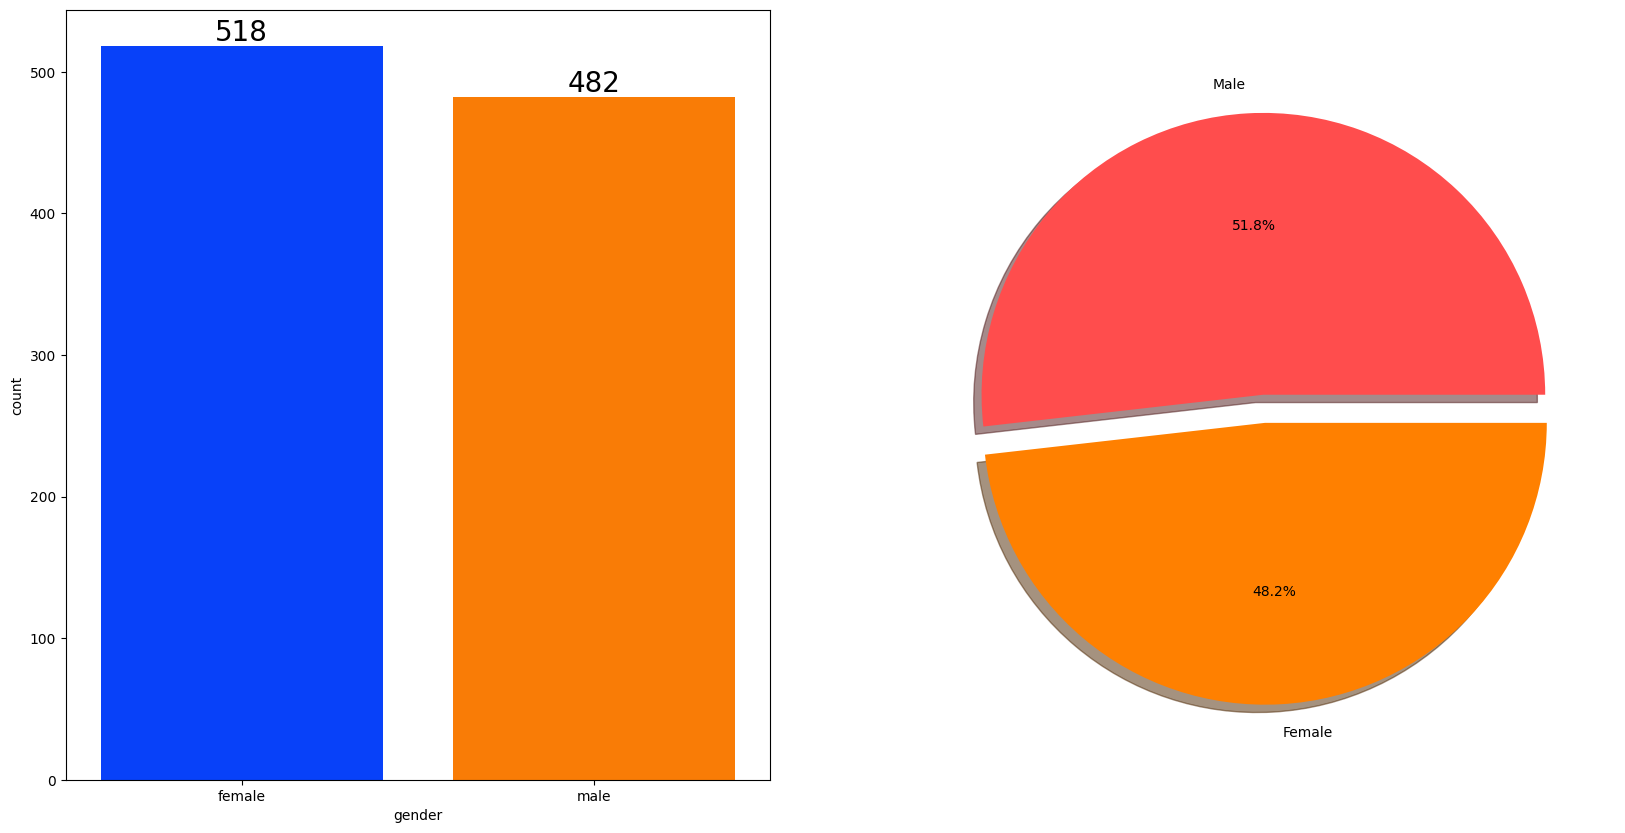

In [25]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [26]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


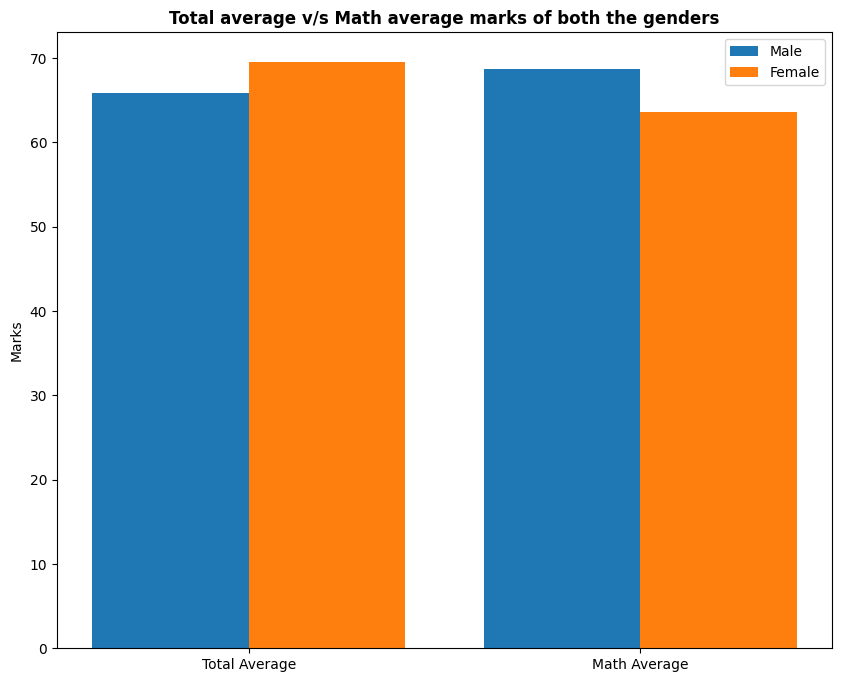

In [27]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [gender_group['average'].loc['female'], gender_group['math_score'].loc['female']]
male_scores = [gender_group['average'].loc['male'], gender_group['math_score'].loc['male']]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

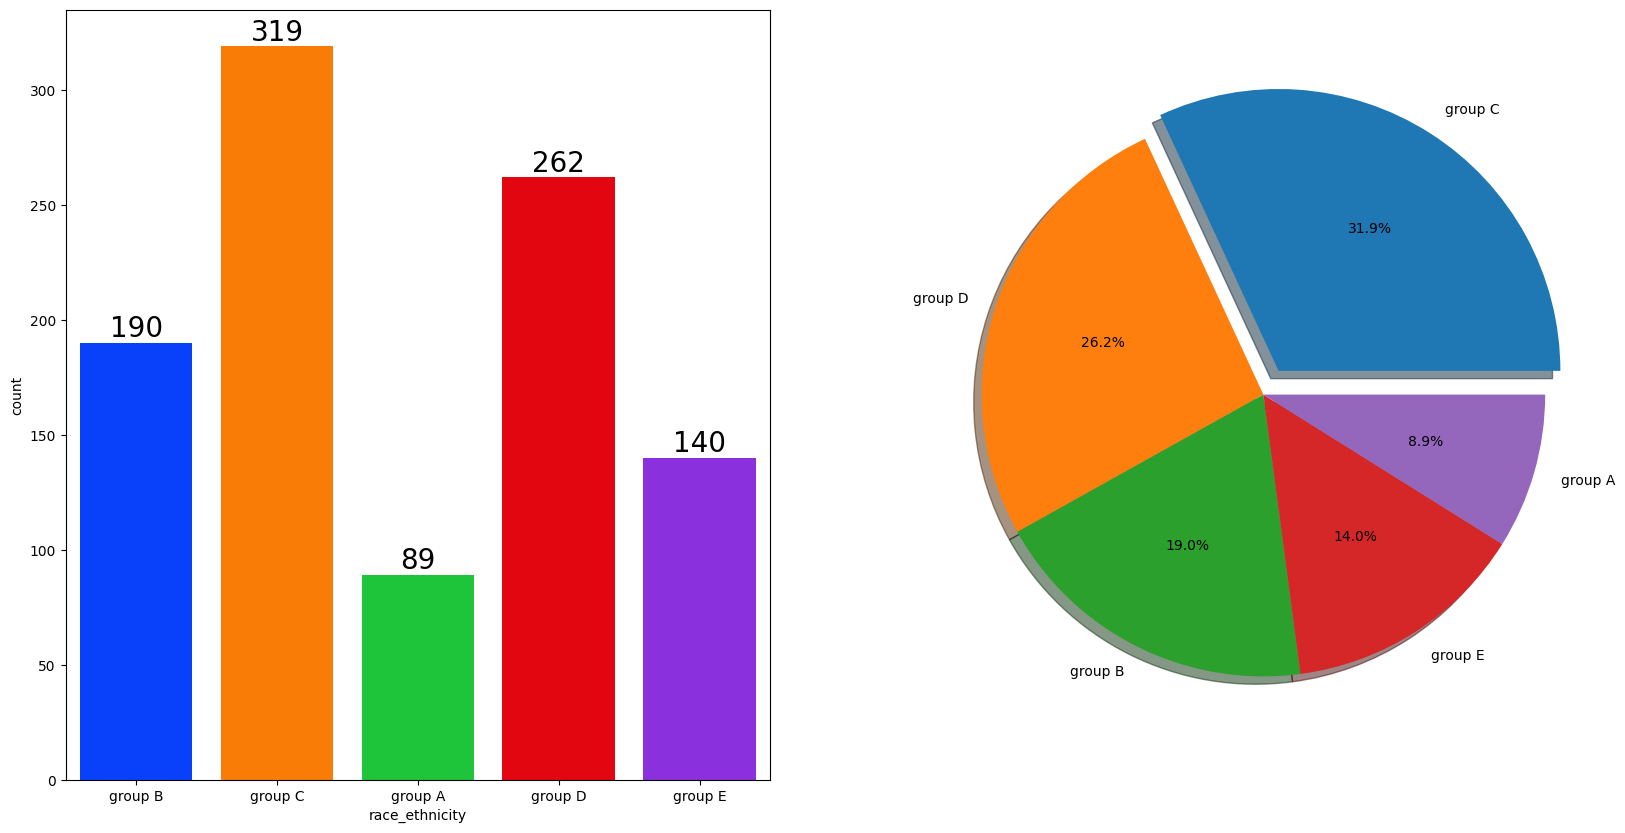

In [28]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

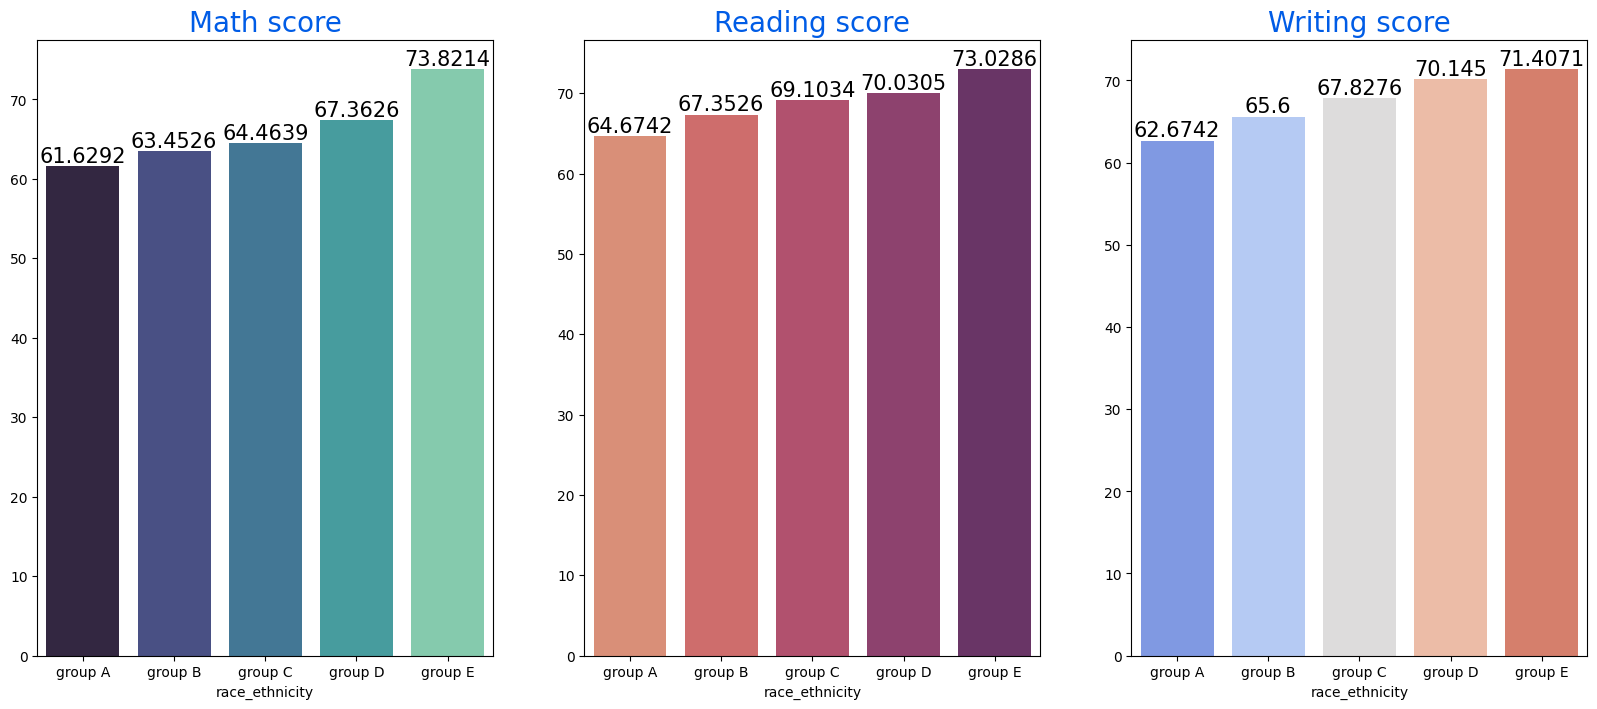

In [29]:
Group_data2 = df.groupby('race_ethnicity')
f, ax = plt.subplots(1, 3, figsize=(20, 8))

sns.barplot(x=Group_data2['math_score'].mean().index, y=Group_data2['math_score'].mean().values, palette='mako', ax=ax[0])
ax[0].set_title('Math score', color='#005ce6', size=20)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index, y=Group_data2['reading_score'].mean().values, palette='flare', ax=ax[1])
ax[1].set_title('Reading score', color='#005ce6', size=20)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index, y=Group_data2['writing_score'].mean().values, palette='coolwarm', ax=ax[2])
ax[2].set_title('Writing score', color='#005ce6', size=20)
for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.show()

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

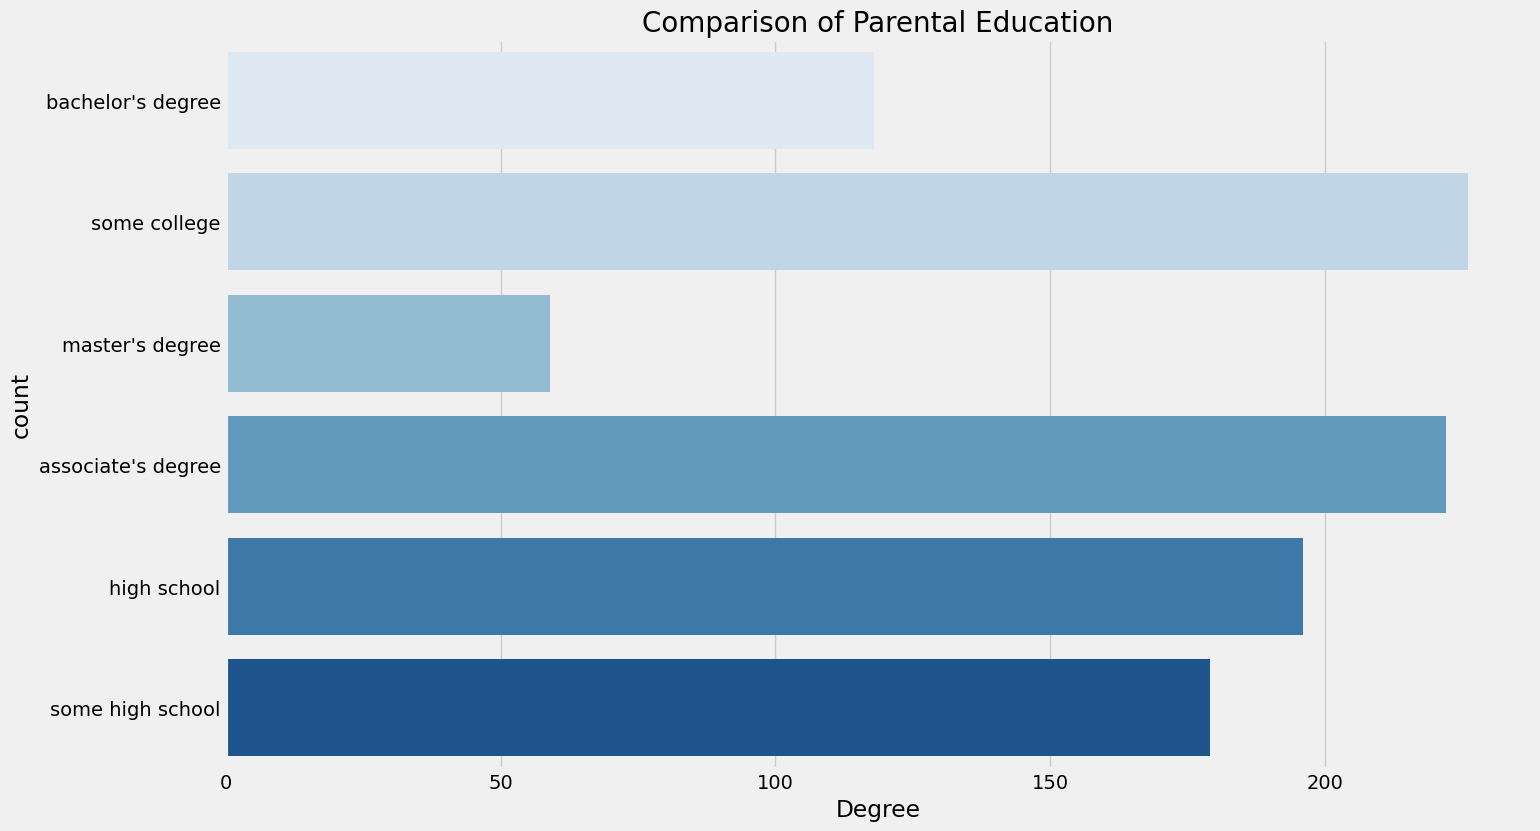

In [30]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

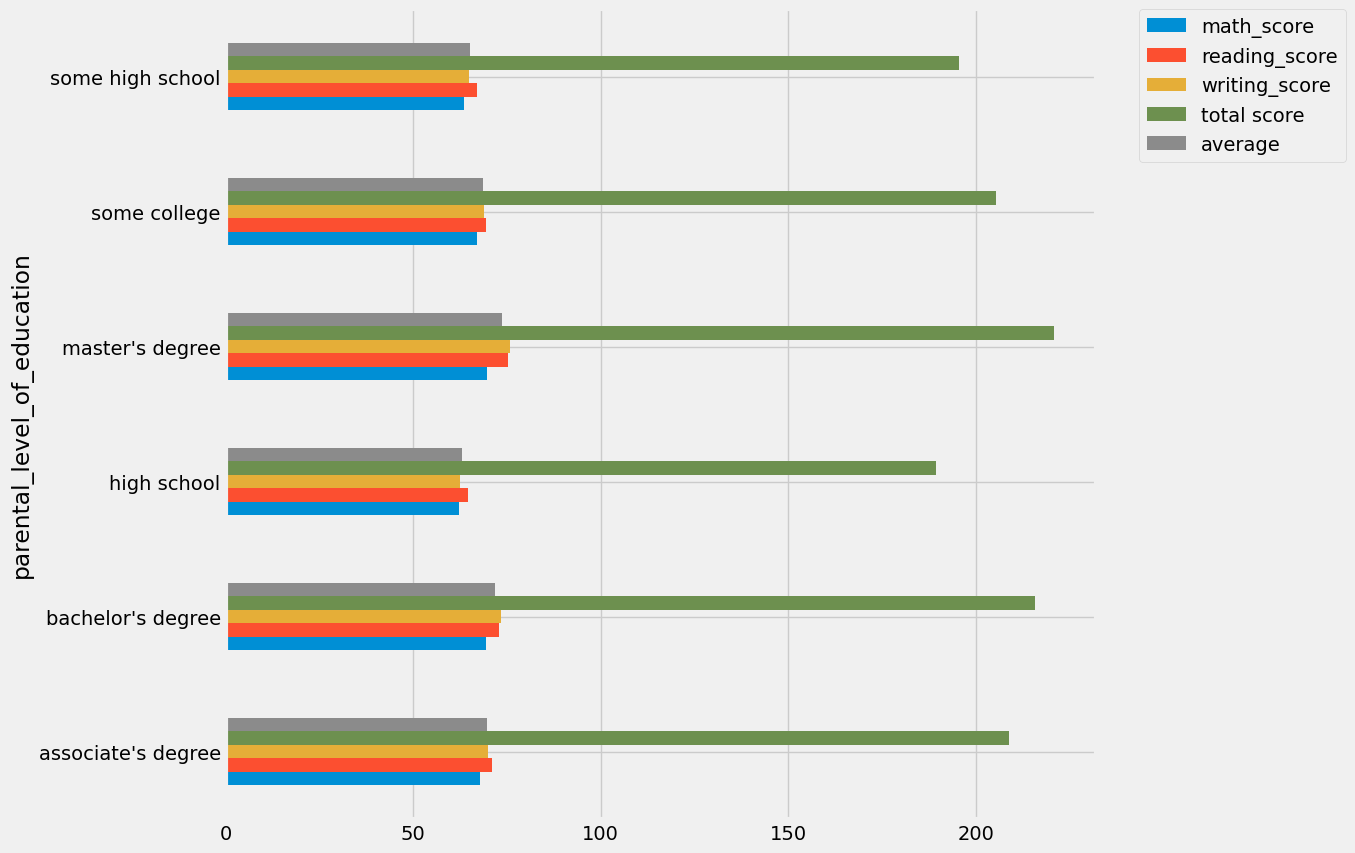

In [31]:
df.groupby('parental_level_of_education').agg('mean', numeric_only=True).plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

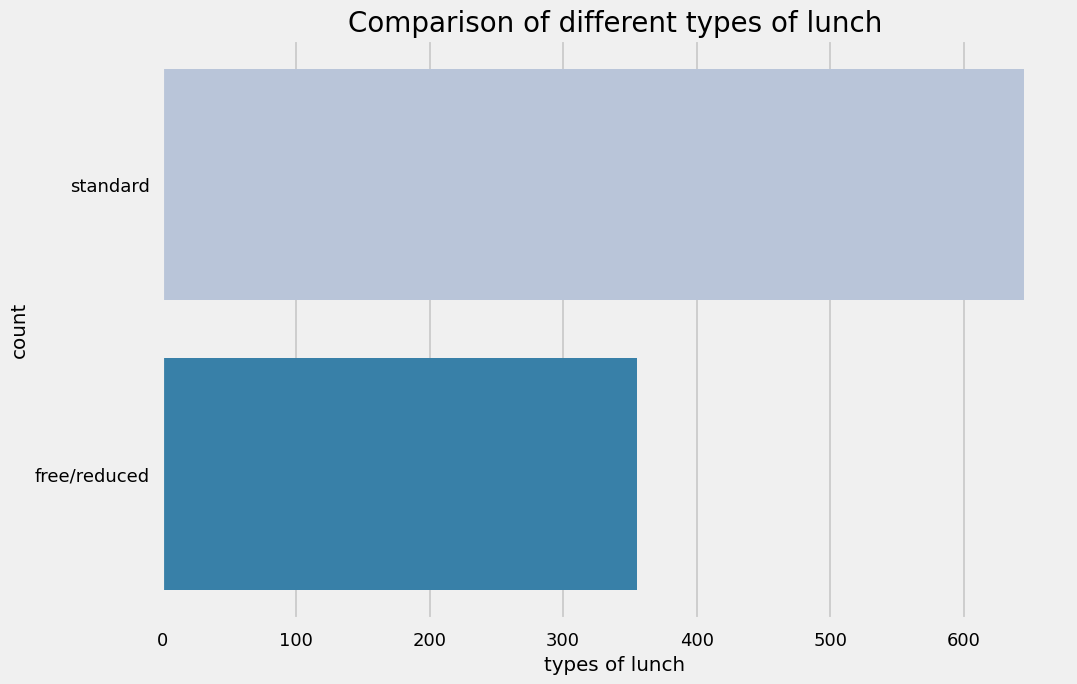

In [32]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

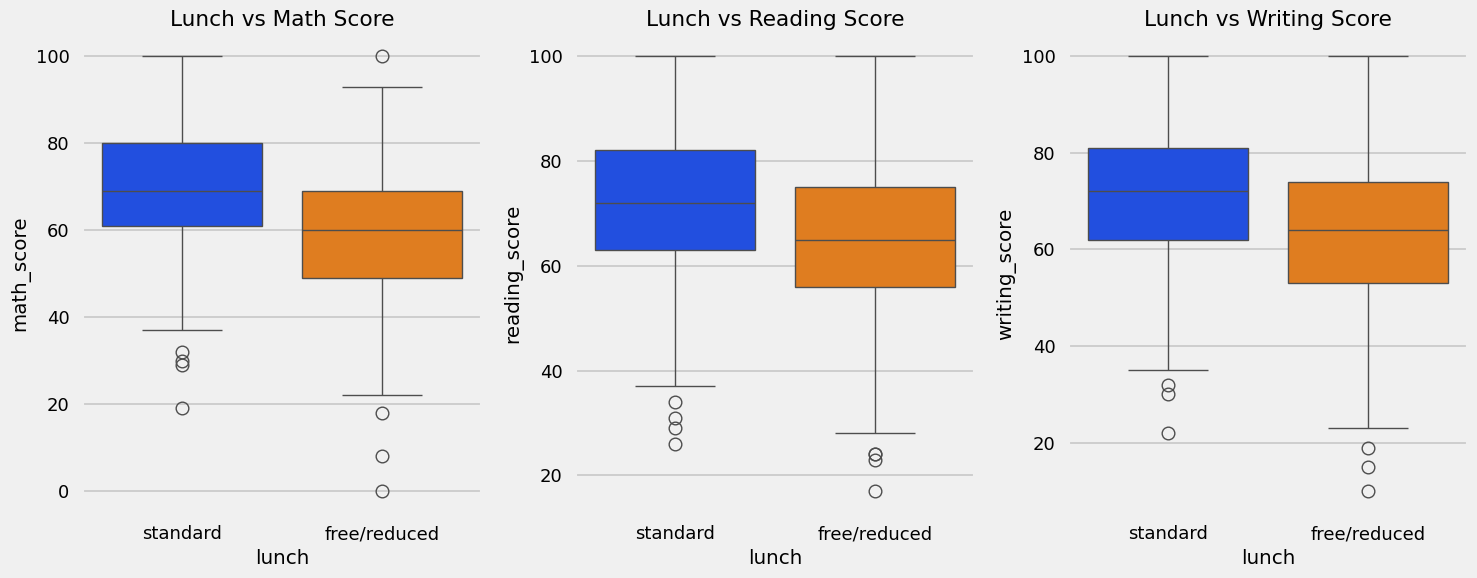

In [40]:
plt.figure(figsize=(15,6))

plt.subplot(131)
sns.boxplot(x='lunch', y='math_score', data=df, palette='bright')
plt.title('Lunch vs Math Score')

plt.subplot(132)
sns.boxplot(x='lunch', y='reading_score', data=df, palette='bright')
plt.title('Lunch vs Reading Score')

plt.subplot(133)
sns.boxplot(x='lunch', y='writing_score', data=df, palette='bright')
plt.title('Lunch vs Writing Score')

plt.tight_layout()
plt.show()

#### Insights 

- Standard lunch students score higher than free/reduced 
  across all 3 subjects
- Biggest gap in math scores
- Free/reduced lunch group has more low-score outliers

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Is Test prepration course has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( Which type of test preparation process is most common amoung students ? )

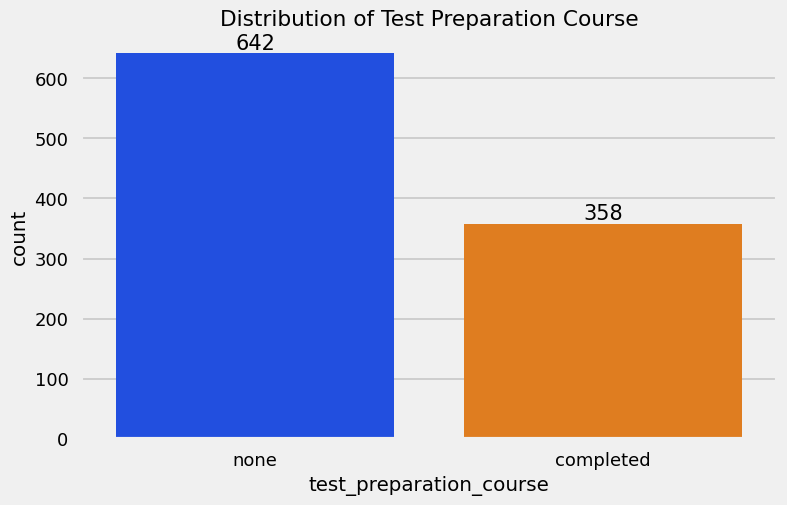

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='test_preparation_course', data=df, palette='bright')
plt.title('Distribution of Test Preparation Course')
for container in plt.gca().containers:
    plt.gca().bar_label(container, color='black', size=15)
plt.show()

#### Insights  

- 642 students (64.2%) did not complete test preparation course
- Only 358 students (35.8%) completed it
- Dataset is imbalanced — almost double the students 
  skipped test preparation

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

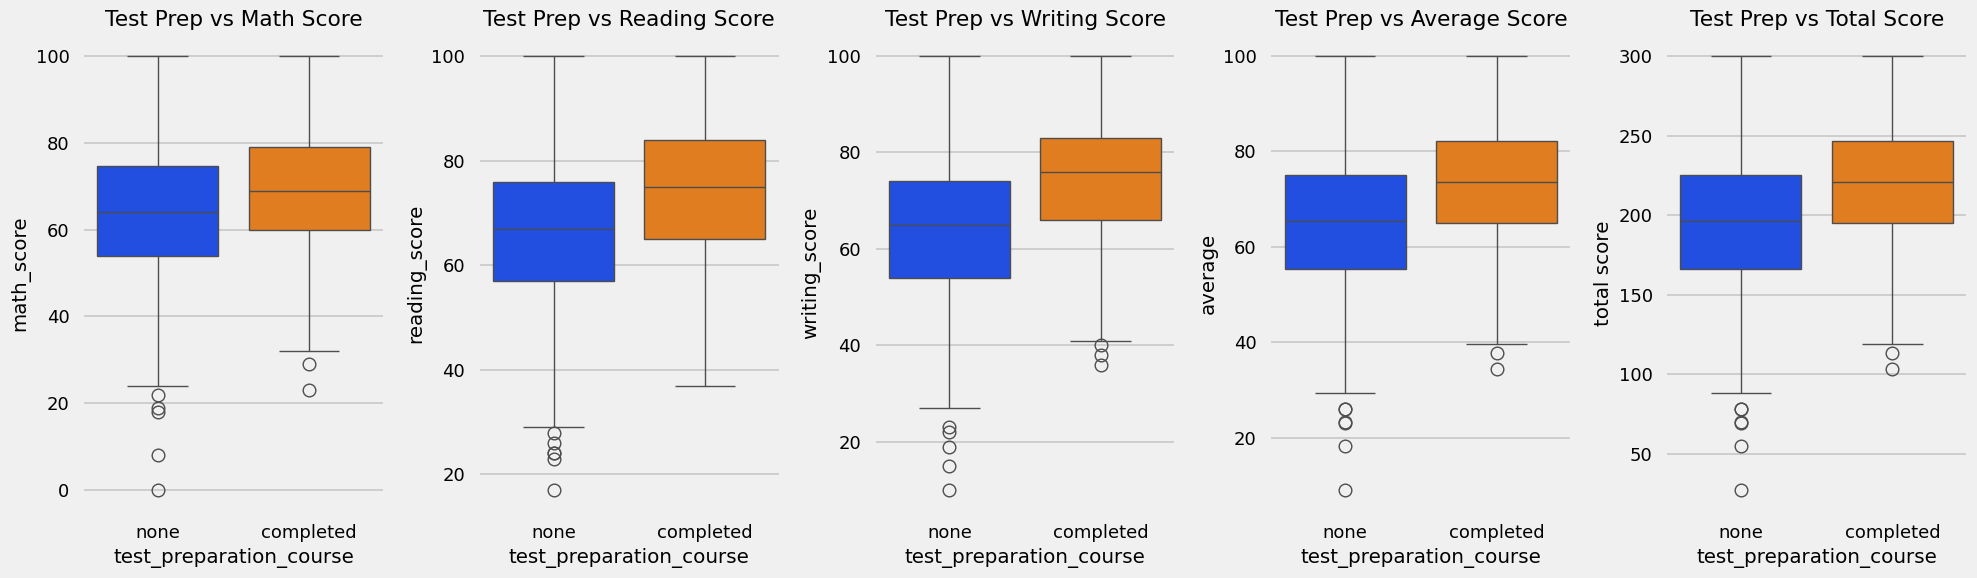

In [46]:
plt.figure(figsize=(20,6))

plt.subplot(151)
sns.boxplot(x='test_preparation_course', y='math_score', data=df, palette='bright')
plt.title('Test Prep vs Math Score')

plt.subplot(152)
sns.boxplot(x='test_preparation_course', y='reading_score', data=df, palette='bright')
plt.title('Test Prep vs Reading Score')

plt.subplot(153)
sns.boxplot(x='test_preparation_course', y='writing_score', data=df, palette='bright')
plt.title('Test Prep vs Writing Score')

plt.subplot(154)
sns.boxplot(x='test_preparation_course', y='average', data=df, palette='bright')
plt.title('Test Prep vs Average Score')

plt.subplot(155)
sns.boxplot(x='test_preparation_course', y='total score', data=df, palette='bright')
plt.title('Test Prep vs Total Score')

plt.tight_layout()
plt.show()

#### Insights  
- Completed test prep students score higher median across 
  all subjects, average and total score

- Biggest improvement seen in Reading and Writing scores
  compared to Math

- "None" group has more low-score outliers across all plots

- Both groups have similar spread (IQR box size) but 
  completed group is consistently shifted higher

- Conclusion: Completing test preparation course positively 
  impacts performance in all subjects

### Impact of Test Preparation Course and Lunch Type on Average Score

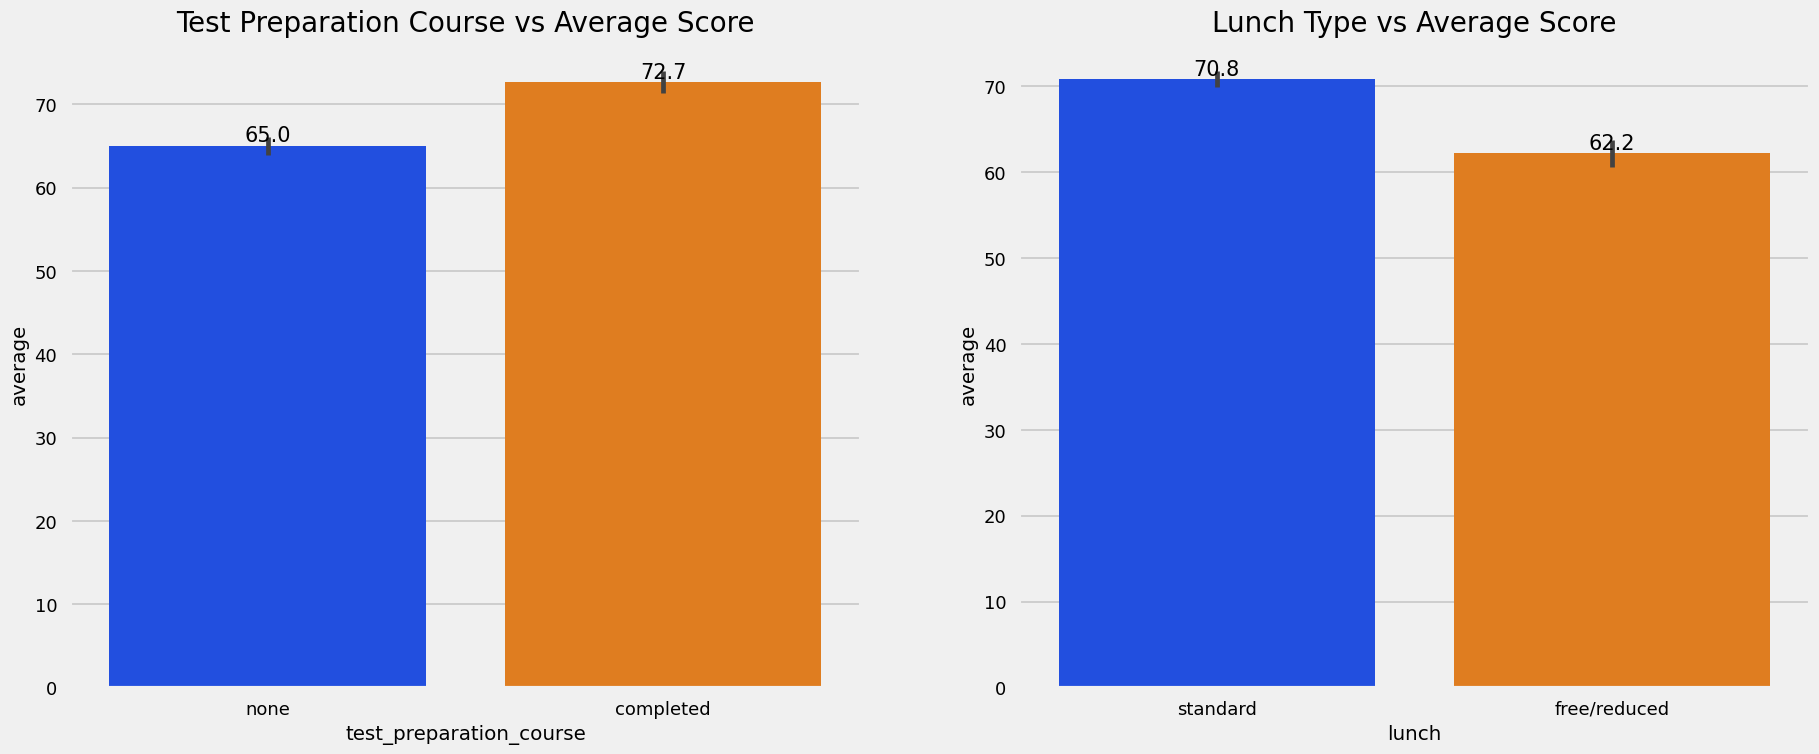

In [44]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='test_preparation_course', y='average', data=df, palette='bright', ax=ax[0])
ax[0].set_title('Test Preparation Course vs Average Score', color='black', size=20)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15, fmt='%.1f')

sns.barplot(x='lunch', y='average', data=df, palette='bright', ax=ax[1])
ax[1].set_title('Lunch Type vs Average Score', color='black', size=20)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15, fmt='%.1f')

plt.show()

#### Insights 
- Completed test prep → average 73.7 vs 65.0 (none) — 8.7 mark difference
- Standard lunch → average 70.8 vs 62.2 (free/reduced) — 8.6 mark difference
- Both factors equally impact student performance

#### 4.4.6 CHECKING OUTLIERS

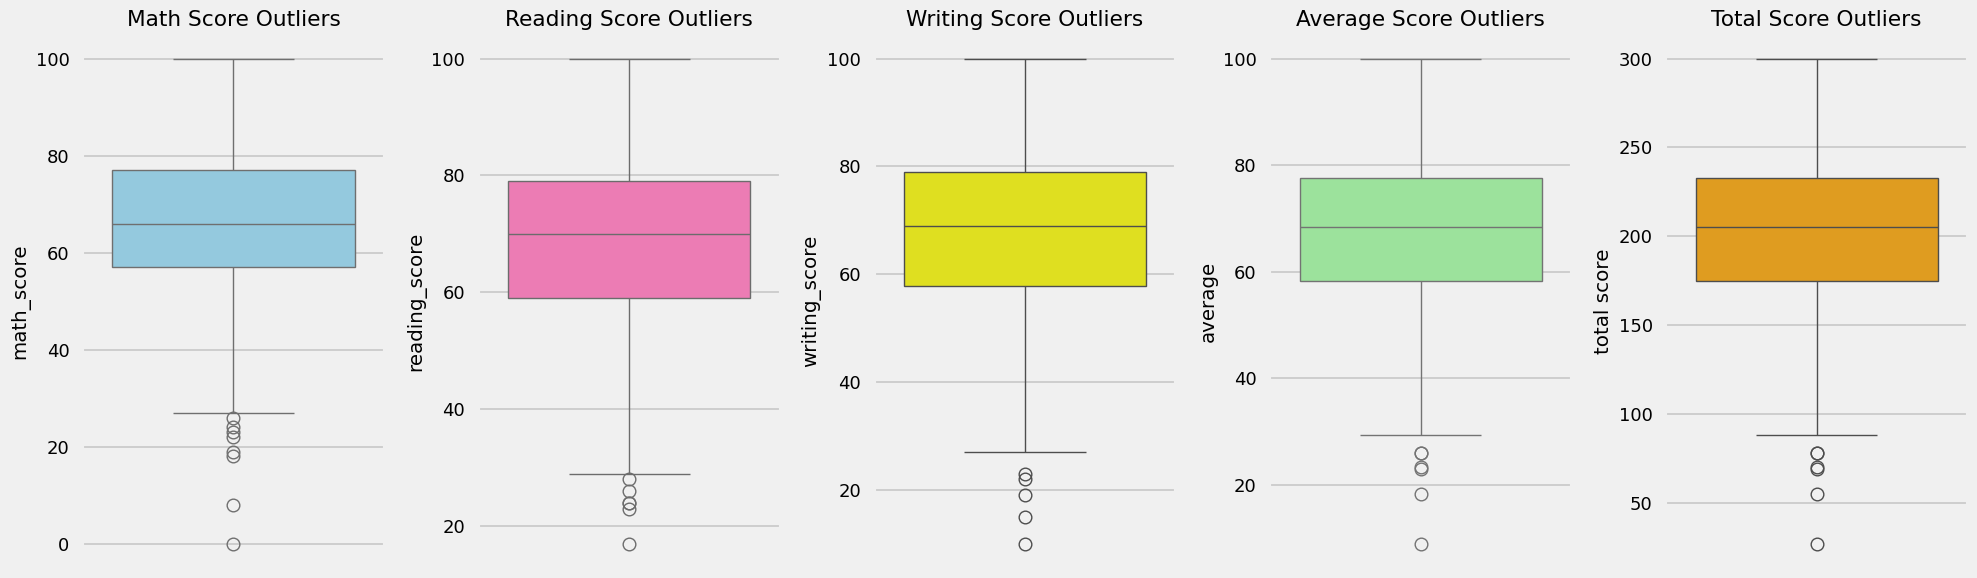

In [47]:
# Checking Outliers
plt.figure(figsize=(20,6))

plt.subplot(151)
sns.boxplot(y=df['math_score'], color='skyblue')
plt.title('Math Score Outliers')

plt.subplot(152)
sns.boxplot(y=df['reading_score'], color='hotpink')
plt.title('Reading Score Outliers')

plt.subplot(153)
sns.boxplot(y=df['writing_score'], color='yellow')
plt.title('Writing Score Outliers')

plt.subplot(154)
sns.boxplot(y=df['average'], color='lightgreen')
plt.title('Average Score Outliers')

plt.subplot(155)
sns.boxplot(y=df['total score'], color='orange')
plt.title('Total Score Outliers')

plt.tight_layout()
plt.show()

In [48]:
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")

find_outliers('math_score')
find_outliers('reading_score')
find_outliers('writing_score')
find_outliers('average')
find_outliers('total score')

math_score: 8 outliers | Lower bound: 27.00 | Upper bound: 107.00
reading_score: 6 outliers | Lower bound: 29.00 | Upper bound: 109.00
writing_score: 5 outliers | Lower bound: 25.88 | Upper bound: 110.88
average: 6 outliers | Lower bound: 29.33 | Upper bound: 106.67
total score: 6 outliers | Lower bound: 88.00 | Upper bound: 320.00


#### Insights
- Math score has the most outliers (8) followed by reading, 
  average and total score (6 each) and writing (5)

- All outliers are on the LOWER end only — upper bounds 
  (107, 109, 110.88) exceed the max score of 100, meaning 
  no student scored unusually high

- Lower bounds confirm a few students scored very low 
  (below 27 in math, below 29 in reading etc.)

- Total of only 5-8 outliers per column out of 1000 students 
  is less than 1% — dataset is relatively clean

- Since outlier count is very small, they can be kept as is 
  without affecting model performance significantly

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

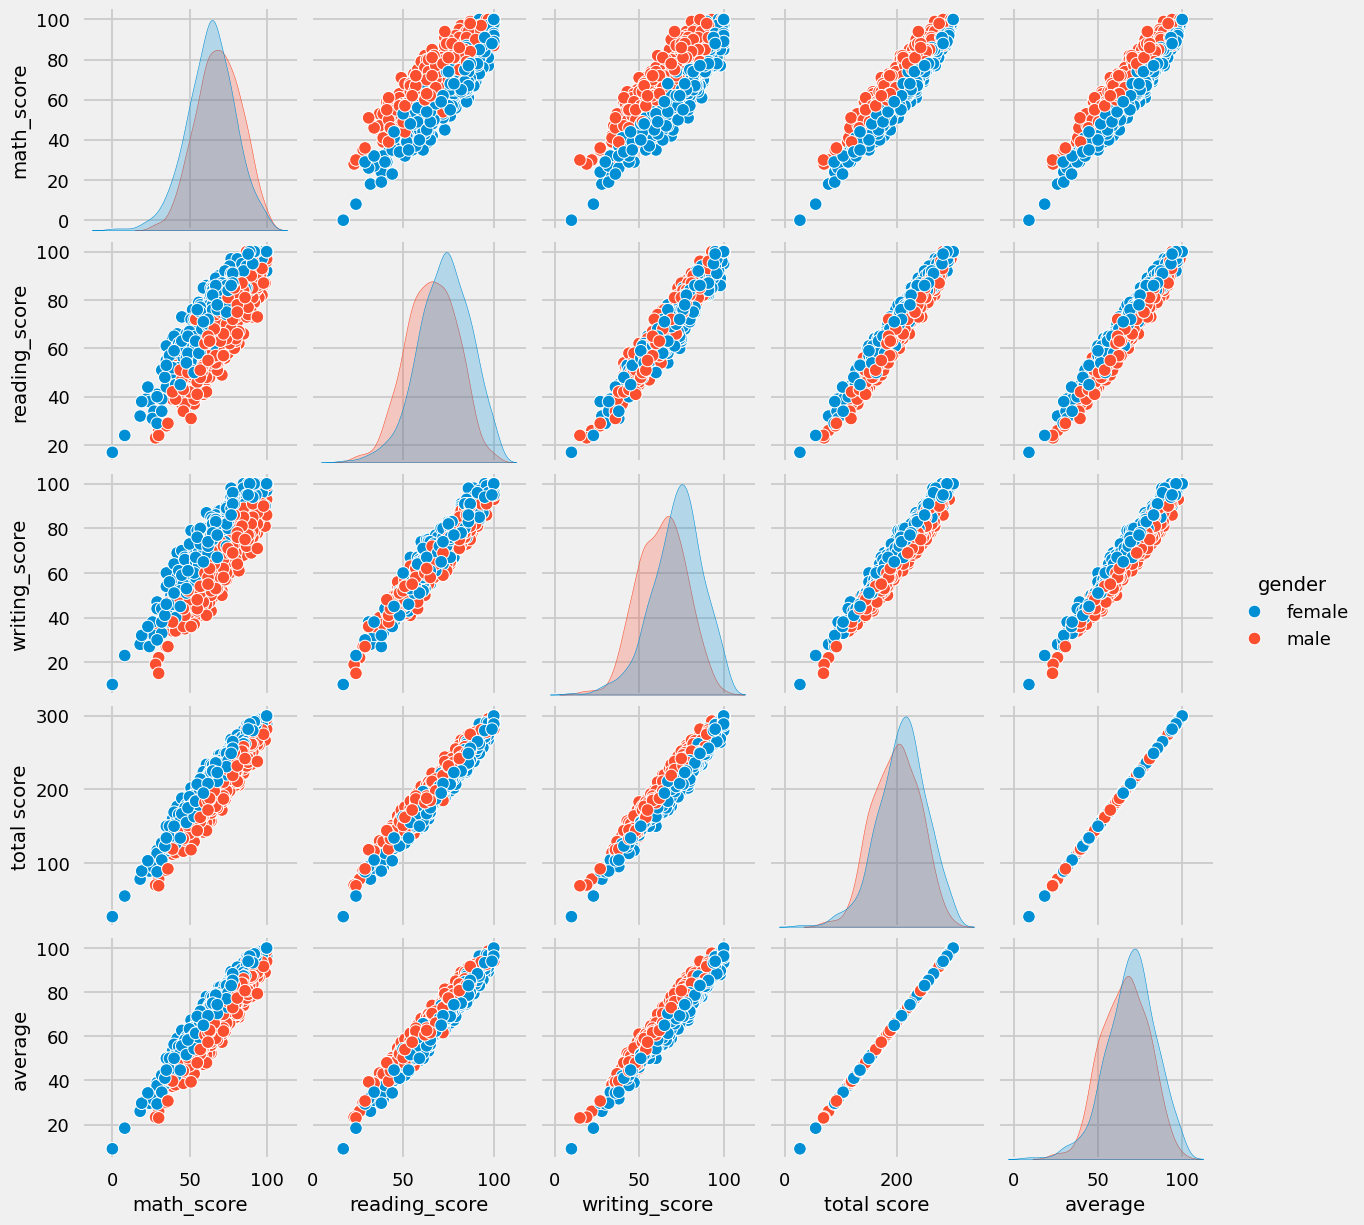

In [50]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

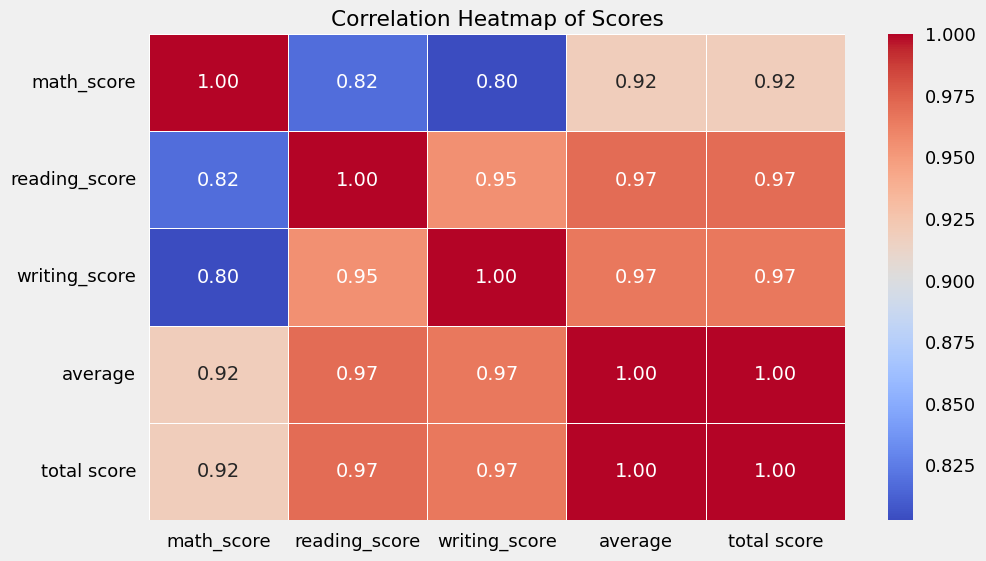

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['math_score','reading_score','writing_score','average','total score']].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap of Scores')
plt.show()

#### Insight
- All scores are highly positively correlated with each other
- Reading & writing have strongest correlation (0.95) — 
  students good at reading tend to be good at writing too
- Math has slightly lower correlation with reading (0.82) 
  and writing (0.80) compared to other pairs
- Average and total score are perfectly correlated (1.00) 
  since average is derived from total score
- All subject scores strongly predict average/total score 
  (0.92-0.97)

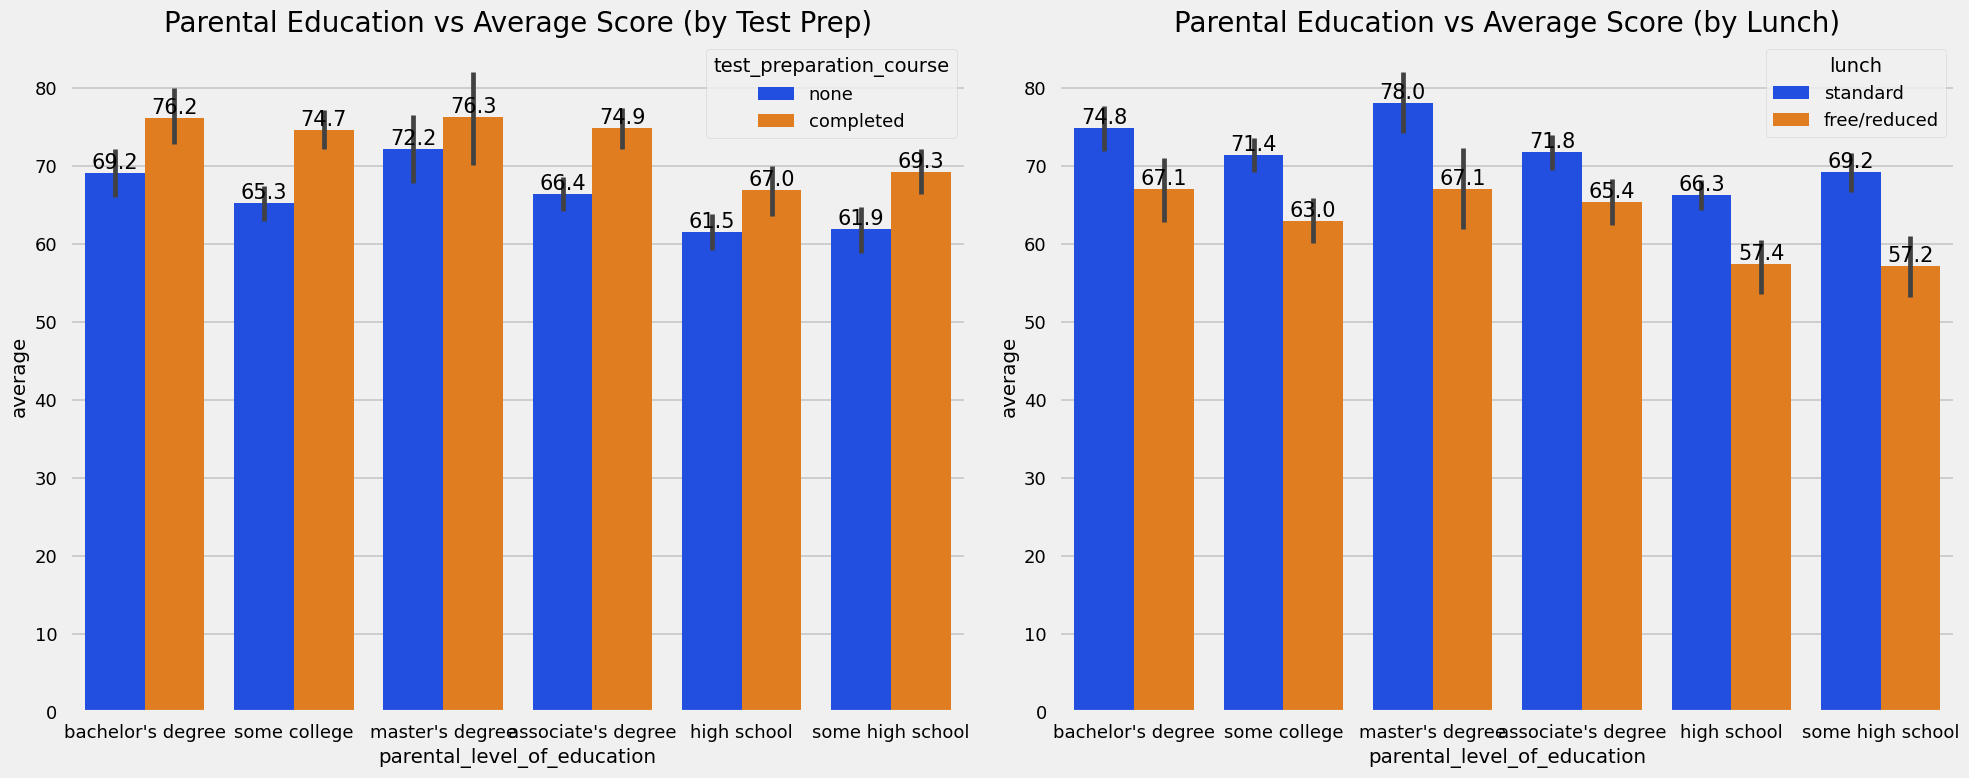

In [52]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))
sns.barplot(x='parental_level_of_education', y='average', data=df, palette='bright', hue='test_preparation_course', ax=ax[0])
ax[0].set_title('Parental Education vs Average Score (by Test Prep)', color='black', size=20)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15, fmt='%.1f')
sns.barplot(x='parental_level_of_education', y='average', data=df, palette='bright', hue='lunch', ax=ax[1])
ax[1].set_title('Parental Education vs Average Score (by Lunch)', color='black', size=20)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15, fmt='%.1f')
plt.tight_layout()
plt.show()

#### Insights
- Completed test prep students score higher than none 
  across ALL parental education groups consistently
- Master's degree parents have highest scoring students 
  (74.7 completed, 72.2 none)
- High school and some high school parent groups score 
  lowest overall
- Standard lunch students outperform free/reduced lunch 
  across every parental education group
- Master's degree + standard lunch combination gives 
  highest average (78.0)
- Some high school + free/reduced lunch gives 
  lowest average (57.2)

### 5. Conclusions

##### Gender
- Dataset is nearly balanced with 51.8% male and 48.2% female students
- Females perform better in reading and writing while males 
  score higher in math
- Overall average scores are comparable between genders

##### Race/Ethnicity
- Group C is the largest group (31.9%) while Group A is smallest (8.9%)
- Group E students are the top performers across all subjects
- Group A students are the lowest performers across all subjects
- There is a clear and consistent performance gap from Group A to Group E

##### Parental Level of Education
- Students with master's degree parents score the highest
- Students with some high school parents score the lowest
- Higher parental education level positively impacts student performance

##### Lunch Type
- Standard lunch students score ~8-9 marks higher than 
  free/reduced lunch students
- This pattern is consistent across all subjects
- Lunch type is one of the strongest performance indicators

##### Test Preparation Course
- Only 35.8% of students completed the test preparation course
- Students who completed scored 8.7 marks higher on average
- Completing test prep benefits both male and female students equally
- Biggest improvement seen in reading and writing scores

##### Overall Summary
- Students from Group E, with master's degree parents, 
  standard lunch and completed test prep are top performers
- Test prep and lunch type are the two strongest predictors 
  of student performance
- All subject scores are highly correlated (0.80-0.97) — 
  students good in one subject tend to be good in others
- Dataset is clean with less than 1% outliers, all low scorers
- Average score will be used as target variable for modeling